# Análise Preditiva - Modelo CART, Random Forest, Xboost and GradientBoostingClassifier
By Iasmin Marques
---


Dados Link da fonte de dados: https://opendatasus.saude.gov.br/dataset/srag-2021-a-2024

Link do repositorio do github https://github.com/iasminimp/srag_tcc


## Informações sobre o DF


Informações sobre as variaveis do dataset

* `FATOR_RISC`: Paciente apresenta algum fator de risco;
Onde:
1-Sim
2-Não
9-Ignorado

`Campo de fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]`

`MORB_DESC`: Listar outro(s) fator(es) de risco do paciente;
e `outros campos de fatores risco`: são padronizados como:

1-Sim

2-Não

9-Ignorado

* `EVOLUCAO`: evolução do caso
Onde,

1-Cura

2-Óbito

3- Óbito por outras causas

9-Ignorado
<br/>


Obs.: o dataset esta desbalanceado, onde no campo de `EVOLUCAO`, temos:

212.812 - 1 CURA

20.207 - 2 Óbito

7.615 - 3 Óbito por outras causas

5.538 - 9-Ignorado


## **TREINAMENTO DE MODELO - CART**

Com a adição das variaveis de idade + sexo + fatores de risco + aprimoramento de 'Ignorado' (9) e NaN nos fatores de risco
*  Converter '9' para NaN para os fatores de risco.

In [2]:

# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score

from imblearn.over_sampling import SMOTE, ADASYN # Adicione ADASYN
# from imblearn.combine import SMOTETomek # Opcional: para over e undersampling combinados
# from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier # Opcional: para outros modelos

# 📌 2. Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)


In [3]:
df

,DT_NOTIFIC,SEM_NOT,DT_SIN_PRI,SEM_PRI,SG_UF_NOT,ID_REGIONA,CO_REGIONA,ID_MUNICIP,CO_MUN_NOT,ID_UNIDADE,...,VG_REINF,REINF,FAB_ADIC,LOT_RE_BI,FAB_RE_BI,DOSE_ADIC,DOS_RE_BI,LOTE_ADIC,TABAG,CASO_SRAG
0,04/01/2024,1,04/01/2024,1,CE,1 CRES FORTALEZA,1519.0,FORTALEZA,230440,SOPAI HOSPITAL INFANTIL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,15/01/2024,3,31/12/2023,1,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,CARDIO PULMONAR DA BAHIA,...,NaN,2,NaN,GF9673,103 - COVID-19 PFIZER - COMIRNATY BIVALENTE,NaN,03/03/2023,NaN,NaN,1.0
2,15/01/2024,3,10/01/2024,2,PB,I NRS JOAO PESSOA,1377.0,JOAO PESSOA,250750,HOSPITAL DE EMERGENCIA E TRAUMA SENADOR HUMBER...,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,11/01/2024,2,04/01/2024,1,GO,SUDOESTE II,1800.0,JATAI,521190,HOSPITAL PADRE TIAGO NA PROVIDENCIA DE DEUS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,16/01/2024,3,14/01/2024,3,BA,NUCLEO REGIONAL DE SAUDE LESTE,1380.0,SALVADOR,292740,PA MARIA DA CONCEICAO SANTIAGO IMBASSAY,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
266425,27/11/2024,48,23/11/2024,47,MG,BELO HORIZONTE,1449.0,BELO HORIZONTE,310620,HOSPITAL INFANTIL JOAO PAULO II,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266426,06/12/2024,49,04/12/2024,49,MG,GOVERNADOR VALADARES,1471.0,GOVERNADOR VALADARES,312770,HOSPITAL MUNICIPAL,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266427,16/12/2024,51,13/12/2024,50,SP,GVE XXXI SOROCABA,1353.0,ITU,352390,VIGILANCIA EPIDEMIOLOGICA,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
266428,05/12/2024,49,04/12/2024,49,DF,NaN,NaN,BRASILIA,530010,HOSPITAL AGUAS CLARAS,...,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0


In [4]:
# 📌 3. Pré-processamento Aprimorado
# Filtrar apenas os registros com evolução "Cura (1)" e "Óbito (2)"
df_filtered = df[df['EVOLUCAO'].isin([1, 2])].copy()

# Mapear valores: 1 → 0 (Cura), 2 → 1 (Óbito)
df_filtered.loc[:, 'EVOLUCAO'] = df_filtered['EVOLUCAO'].map({1: 0, 2: 1})

# Lista de colunas com fatores de risco
fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

# Converter '9' para NaN para os fatores de risco.
# O `.dropna()` posterior removerá as linhas com NaN nessas colunas.
df_filtered.loc[:, fatores_risco] = df_filtered[fatores_risco].apply(pd.to_numeric, errors='coerce')

# Tratamento da coluna NU_IDADE_N (Idade)
# Converte para numérico. Valores não numéricos se tornam NaN.
df_filtered.loc[:, 'NU_IDADE_N'] = pd.to_numeric(df_filtered['NU_IDADE_N'], errors='coerce')

# Tratamento da coluna CS_SEXO (Sexo)
# Mapeia 'M' para 0 e 'F' para 1. 'I' (Ignorado) e outros valores se tornam NaN.
df_filtered.loc[:, 'CS_SEXO'] = df_filtered['CS_SEXO'].map({'M': 0, 'F': 1})
# Para 'I' (Ignorado), Deixei como NaN e remover na etapa de dropna

# Remover linhas com valores ausentes nas colunas essenciais
# Isso garantirá que estamos usando apenas registros completos para essas features.
colunas_essenciais = fatores_risco + ['EVOLUCAO', 'NU_IDADE_N', 'CS_SEXO']
df_filtered.dropna(subset=colunas_essenciais, inplace=True)

# Separar variáveis preditoras (X) e variável alvo (y)
# Adicione 'NU_IDADE_N' e 'CS_SEXO' à sua lista de features preditoras.
X = df_filtered[fatores_risco + ['NU_IDADE_N', 'CS_SEXO']]
y = df_filtered['EVOLUCAO']

# Verificação das primeiras linhas de X e y após o pré-processamento
print("Primeiras linhas de X após pré-processamento:")
print(X.head())
print("\nDistribuição de y após pré-processamento:")
print(y.value_counts())

Primeiras linhas de X após pré-processamento:
    PUERPERA  CARDIOPATI  HEMATOLOGI  SIND_DOWN  HEPATICA  ASMA  DIABETES  \
3        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
9        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
10       2.0         1.0         2.0        2.0       2.0   2.0       2.0   
12       2.0         2.0         2.0        2.0       2.0   2.0       2.0   
14       2.0         2.0         2.0        2.0       2.0   2.0       2.0   

    NEUROLOGIC  PNEUMOPATI  IMUNODEPRE  RENAL  OBESIDADE  OUT_MORBI  \
3          2.0         2.0         2.0    2.0        2.0        1.0   
9          2.0         2.0         2.0    2.0        2.0        2.0   
10         2.0         2.0         2.0    2.0        2.0        1.0   
12         2.0         2.0         1.0    2.0        2.0        1.0   
14         2.0         1.0         2.0    2.0        2.0        2.0   

    NU_IDADE_N CS_SEXO  
3           72     0.0  
9           63

In [5]:
# 📌 4. Balanceamento (Experimentar ADASYN ou class_weight)
print(f"Balanceamento antes: \n{y.value_counts()}")

#SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print(f"Balanceamento depois: \n{y_res.value_counts()}")

Balanceamento antes: 
EVOLUCAO
0.0    50301
1.0     9533
Name: count, dtype: int64
Balanceamento depois: 
EVOLUCAO
1.0    50301
0.0    50301
Name: count, dtype: int64


In [6]:
# 📌 5. Treinamento e Otimização do Modelo (com Validação Cruzada e Grid Search)
# Divisão em treino e teste (mantida para avaliação final, mas validação cruzada será usada no Grid Search)
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.3, random_state=42, stratify=y_res) # stratify para manter proporção

# **Aprimoramento 3: Grid Search para encontrar os melhores hiperparâmetros**
clf = DecisionTreeClassifier(random_state=42)

# Definir os parâmetros a serem testados
param_grid = {
    'max_depth': [3, 5, 7, 10, None], # None = profundidade total
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'criterion': ['gini', 'entropy']
}

# Usar StratifiedKFold para validação cruzada, mantendo a proporção de classes
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Configurar o GridSearchCV
# O scoring deve ser baseado na métrica que você mais valoriza (ex: 'f1' para a classe minoritária, 'recall' para 'óbitos')
# 'f1_macro' ou 'f1_weighted' são boas opções para balancear ambas as classes
grid_search = GridSearchCV(estimator=clf, param_grid=param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-Score (macro) na validação cruzada: {grid_search.best_score_:.4f}")

# Obter o melhor modelo
best_clf = grid_search.best_estimator_

# talvez TREINAR OUTROS MODELOS ***

Fitting 5 folds for each of 90 candidates, totalling 450 fits

Melhores parâmetros encontrados: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5}
Melhor F1-Score (macro) na validação cruzada: 0.7621


In [17]:
# 📌 6. Avaliação Abrangente
y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict_proba(X_test)[:, 1] # Probabilidades para a classe positiva (Óbito)

print("\n--- Avaliação do Melhor Modelo CART ---")
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

# Calcular Métricas Específicas para Óbito (Classe 1)
precision_óbitos = precision_score(y_test, y_pred, pos_label=1)
recall_óbitos = recall_score(y_test, y_pred, pos_label=1)
f1_óbitos = f1_score(y_test, y_pred, pos_label=1)

print(f"\nPrecisão para Óbito: {precision_óbitos:.2f}")
print(f"Recall para Óbito: {recall_óbitos:.2f}")
print(f"F1-Score para Óbito: {f1_óbitos:.2f}")


--- Avaliação do Melhor Modelo CART ---
📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.73      0.76     15091
         1.0       0.75      0.81      0.78     15090

    accuracy                           0.77     30181
   macro avg       0.77      0.77      0.77     30181
weighted avg       0.77      0.77      0.77     30181


Precisão para Óbito: 0.75
Recall para Óbito: 0.81
F1-Score para Óbito: 0.78



Matriz de Confusão:


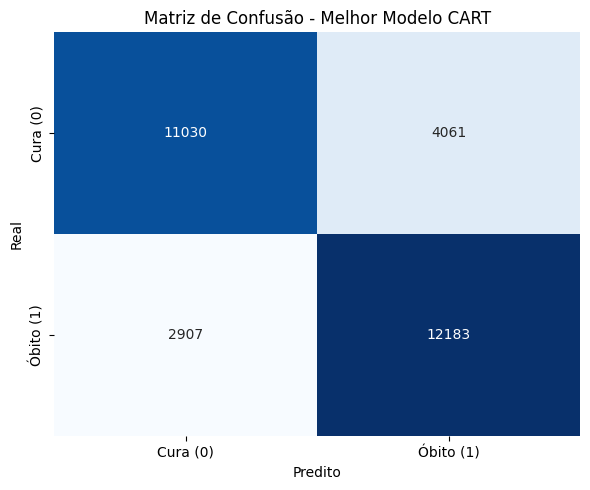

In [15]:
print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Melhor Modelo CART')
plt.tight_layout()
plt.show()

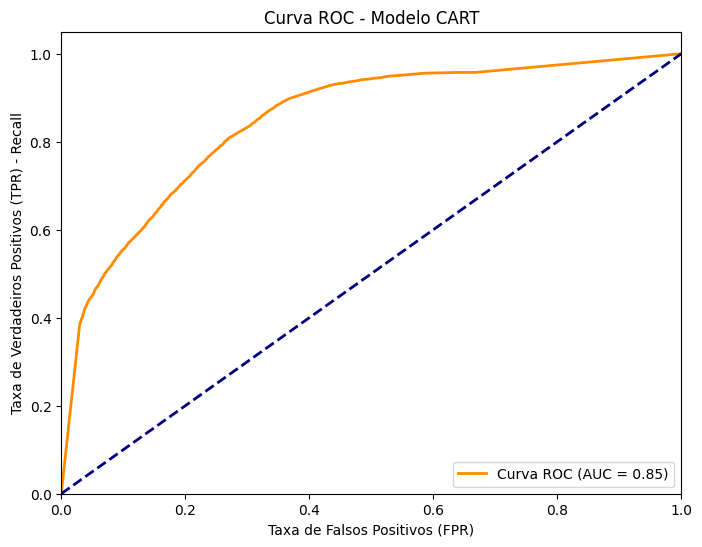


AUC do Modelo: 0.85


In [13]:
# Curva ROC e AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Curva ROC - Modelo CART')
plt.legend(loc="lower right")
plt.show()
print(f"\nAUC do Modelo: {roc_auc:.2f}")

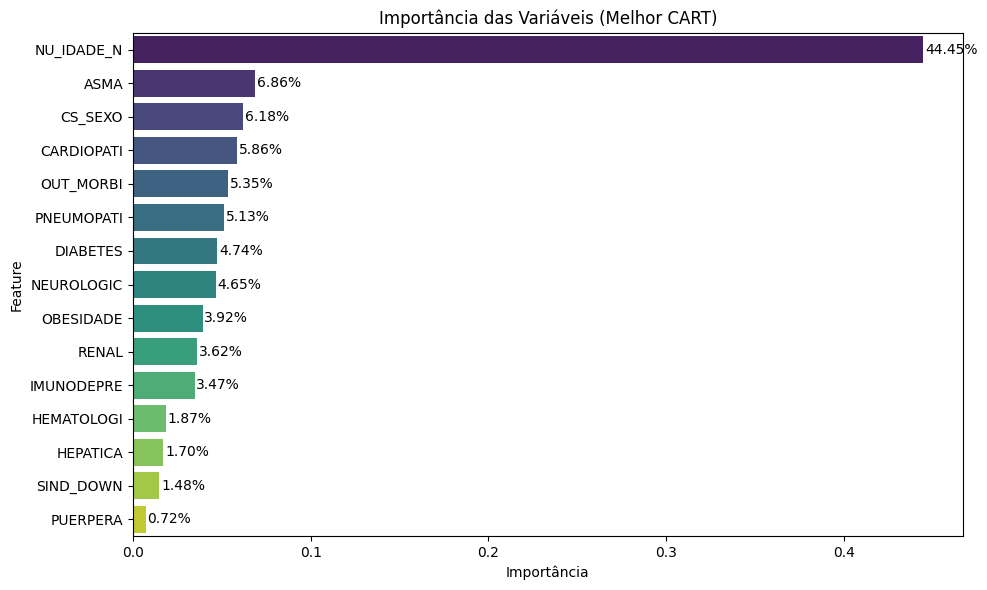

In [16]:
# 📌 7. Importância das features (do melhor modelo)
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': best_clf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
#sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis')
sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Variáveis (Melhor CART)')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()

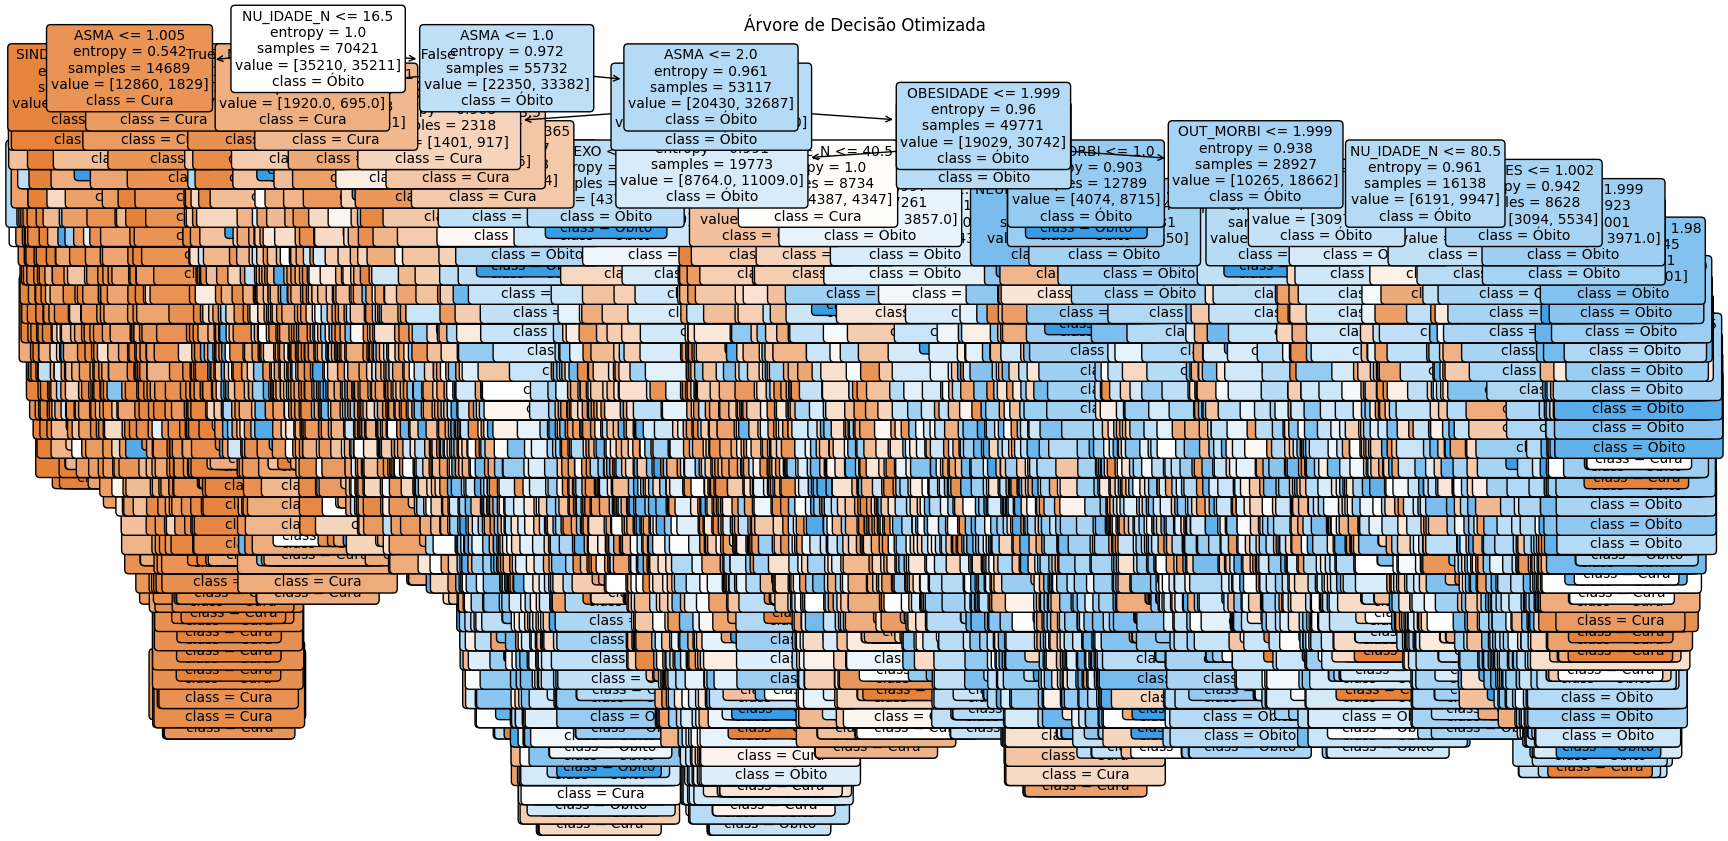

In [9]:
# 📌 8. Visualização da árvore (do melhor modelo)
plt.figure(figsize=(20,10))
plot_tree(best_clf, feature_names=X.columns, class_names=['Cura', 'Óbito'], filled=True, rounded=True, fontsize=10)
plt.title('Árvore de Decisão Otimizada')
plt.show()

### Possiveis melhorias para o modelo

 **Melhorias**



1. Sugestões de Como Avaliar o Seu Modelo
Você já está fazendo uma avaliação muito boa com o Classification Report, Matriz de Confusão, Curva ROC e AUC, além da importância das features. Para aprimorar ainda mais, considere:

> Análise de Erros Específicos:

* Falsos Positivos (FP) e Falsos Negativos (FN): Olhe para os casos específicos onde o modelo errou.
Falsos Positivos (FP): Casos que o modelo previu como "Óbito" (1), mas que na verdade foram "Cura" (0). Entender o porquê desses casos serem classificados erroneamente pode indicar features enganosas ou padrões que o modelo não capturou bem.
Falsos Negativos (FN): Casos que o modelo previu como "Cura" (0), mas que na verdade foram "Óbito" (1). Estes são geralmente os erros mais críticos em cenários de saúde, pois um óbito previsto como cura significa perda de oportunidade de intervenção. Investigar esses casos é crucial para entender o que faltou ao modelo para identificá-los corretamente.
* Análise de Limiar (Threshold Analysis): Para modelos de classificação binária, o limiar padrão de 0.5 para classificar as probabilidades em 0 ou 1 pode não ser o ideal, especialmente em problemas com classes desbalanceadas ou com custos de erro assimétricos (como FNs).
Você pode plotar o Precision-Recall Curve e analisar como a Precisão e o Recall variam com diferentes limiares. Isso pode te ajudar a escolher um limiar que otimize o balanço entre FPs e FNs, dependendo do que é mais crítico para a aplicação (minimizar falsos positivos ou falsos negativos). Dado que a classe 1 (Óbito) é a minoritária e provavelmente a de maior interesse, maximizar o Recall (reduzir FNs) para esta classe pode ser prioritário, mesmo que isso custe um pouco de Precisão.
* Validação Cruzada Detalhada: Embora você já use StratifiedKFold no GridSearchCV, você pode reportar as métricas para cada fold individualmente, além da média. Isso oferece uma visão da estabilidade do modelo em diferentes subconjuntos dos dados.

* Curva de Calibração (Reliability Diagram): Avalia o quão "calibradas" as probabilidades de saída do seu modelo são. Se o modelo diz que um paciente tem 80% de chance de óbito, ele realmente tem 80% de chance de óbito? Isso é importante em aplicações críticas onde a confiança nas probabilidades é tão importante quanto a própria classificação.



2. Formas de Como Melhorar o Modelo
Seu modelo já está com um bom ponto de partida, mas podemos explorar algumas direções:

> Engenharia de Features:

* Interações entre Fatores de Risco: A combinação de dois ou mais fatores de risco pode ter um impacto maior do que a soma das partes. Por exemplo, "DIABETES" e "CARDIOPATI" juntas podem ser mais preditivas. Você pode criar novas features que representam essas interações (ex: df['DIABETES_CARDIOPATI'] = df['DIABETES'] * df['CARDIOPATI']);

*   Categorização de Idade: A idade (NU_IDADE_N) é a feature mais importante. Você pode tentar transformá-la em faixas etárias (ex: 0-12, 13-18, 19-60, >60) se fizer sentido clinicamente. Isso pode ajudar o modelo a capturar não linearidades específicas da idade.

* Explorar MORB_DESC (Se possível): Você mencionou MORB_DESC que lista outros fatores. Se essa coluna contiver texto livre e relevante, você poderia usar técnicas de Processamento de Linguagem Natural (PLN) para extrair informações e criar novas features. Isso seria um projeto mais complexo, mas com potencial alto.

* Outras Features no DataFrame Original: Dê uma olhada no DataFrame original (df). Existem outras colunas que poderiam ser úteis após o pré-processamento? Por exemplo, a data de início dos sintomas (DT_SIN_PRI), a classificação final (CLASSI_FIN), ou outras informações demográficas/clínicas que não foram usadas ainda.

> Estratégias de Balanceamento:

* Experimentar ADASYN: Você já importou o ADASYN, que é uma ótima alternativa ao SMOTE. Enquanto o SMOTE gera amostras sintéticas entre vizinhos próximos, o ADASYN se concentra em gerar amostras para os exemplos da classe minoritária que são mais difíceis de classificar (aqueles que estão mais próximos da fronteira de decisão). Tente substituir SMOTE por ADASYN e veja se há melhora.
* Combinação de Over- e Under-sampling: Bibliotecas como imblearn.combine.SMOTETomek ou SMOTEENN podem ser úteis. Elas primeiro aplicam oversampling e depois undersampling para limpar o ruído gerado. Isso pode resultar em um conjunto de dados mais limpo e melhor aprendizado.
* Ajuste de class_weight: Para modelos como Árvores de Decisão, você pode usar o parâmetro class_weight='balanced' diretamente no construtor do modelo (DecisionTreeClassifier(class_weight='balanced', ...)) em vez de usar SMOTE. Isso ajusta os pesos das classes durante o treinamento, dando mais importância à classe minoritária. Você pode testar isso como alternativa ao SMOTE para ver qual abordagem funciona melhor.

> Experimentar Outros Modelos (Ensemble Methods):

* Random Forest: É um ensemble de árvores de decisão e geralmente performa melhor que uma única árvore devido à redução de overfitting e à média de previsões. RandomForestClassifier é uma ótima próxima etapa.

* Gradient Boosting (e.g., LightGBM, XGBoost, CatBoost): Modelos de gradient boosting são extremamente poderosos para dados tabulares e costumam obter resultados de ponta. Eles constroem árvores sequencialmente, corrigindo os erros das árvores anteriores. Vale a pena explorar.

* Suporte Vector Machine (SVM) ou Redes Neurais (DNN): Se os dados forem mais complexos e você tiver recursos computacionais, modelos mais avançados podem capturar padrões ainda mais intrincados.

> Otimização de Hiperparâmetros (Grid Search/Randomized Search):

* Expandir o param_grid: Para os modelos que você experimentar (Random Forest, LightGBM, etc.), explore uma gama maior de hiperparâmetros ou use RandomizedSearchCV que é mais eficiente para espaços de busca grandes.
* Otimização Bayesiana: Para otimizações mais avançadas e eficientes, você pode usar bibliotecas como Hyperopt ou Optuna para encontrar os melhores hiperparâmetros de forma mais inteligente do que um Grid Search exaustivo.



### Random Forest

In [19]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score

from imblearn.over_sampling import SMOTE

# 📌 2. Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)



Primeiras linhas de X após pré-processamento:
    PUERPERA  CARDIOPATI  HEMATOLOGI  SIND_DOWN  HEPATICA  ASMA  DIABETES  \
3        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
9        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
10       2.0         1.0         2.0        2.0       2.0   2.0       2.0   
12       2.0         2.0         2.0        2.0       2.0   2.0       2.0   
14       2.0         2.0         2.0        2.0       2.0   2.0       2.0   

    NEUROLOGIC  PNEUMOPATI  IMUNODEPRE  RENAL  OBESIDADE  OUT_MORBI  \
3          2.0         2.0         2.0    2.0        2.0        1.0   
9          2.0         2.0         2.0    2.0        2.0        2.0   
10         2.0         2.0         2.0    2.0        2.0        1.0   
12         2.0         2.0         1.0    2.0        2.0        1.0   
14         2.0         1.0         2.0    2.0        2.0        2.0   

    NU_IDADE_N CS_SEXO  
3           72     0.0  
9           63

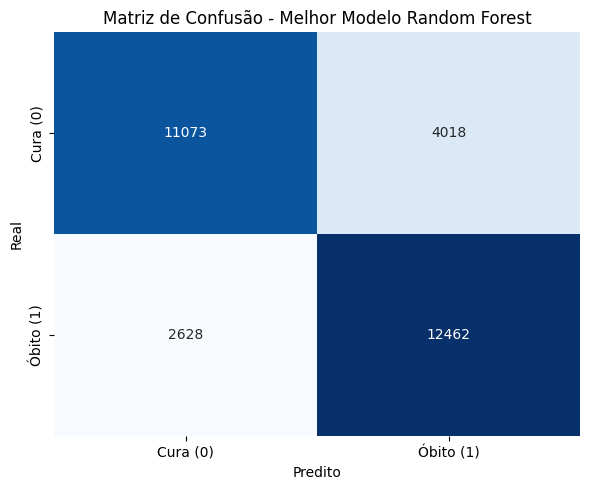

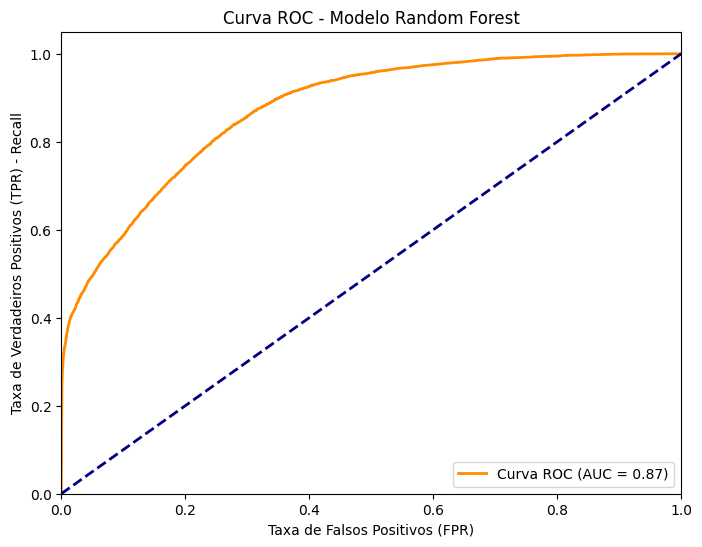


AUC do Modelo: 0.87


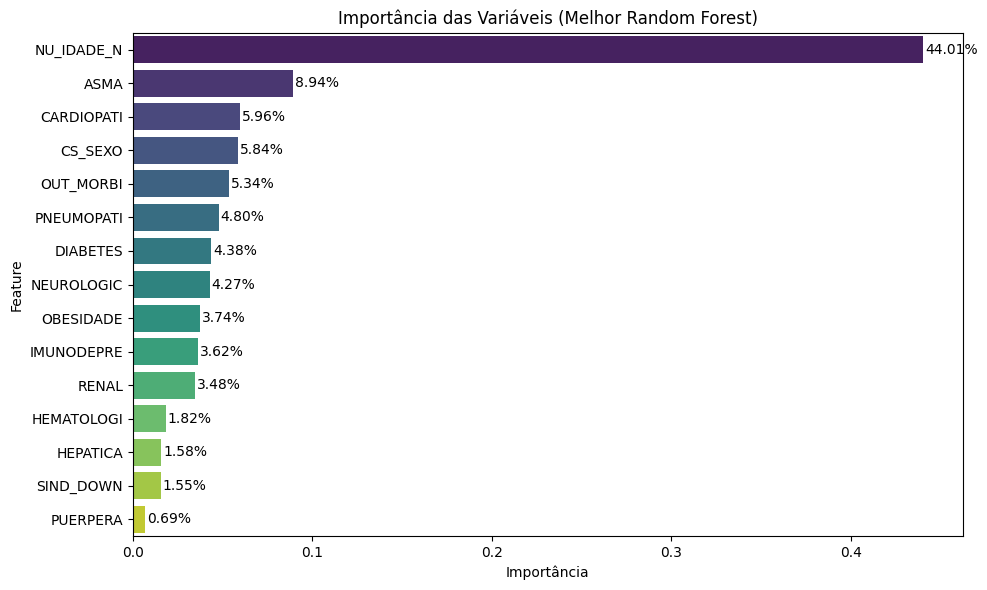

In [20]:
# 📌 3. Pré-processamento
df_filtered = df[df['EVOLUCAO'].isin([1, 2])].copy()
df_filtered.loc[:, 'EVOLUCAO'] = df_filtered['EVOLUCAO'].map({1: 0, 2: 1})

fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

df_filtered.loc[:, fatores_risco] = df_filtered[fatores_risco].apply(pd.to_numeric, errors='coerce')
df_filtered.loc[:, 'NU_IDADE_N'] = pd.to_numeric(df_filtered['NU_IDADE_N'], errors='coerce')
df_filtered.loc[:, 'CS_SEXO'] = df_filtered['CS_SEXO'].map({'M': 0, 'F': 1})

colunas_essenciais = fatores_risco + ['EVOLUCAO', 'NU_IDADE_N', 'CS_SEXO']
df_filtered.dropna(subset=colunas_essenciais, inplace=True)

X = df_filtered[fatores_risco + ['NU_IDADE_N', 'CS_SEXO']]
y = df_filtered['EVOLUCAO']

print("Primeiras linhas de X após pré-processamento:")
print(X.head())
print("\nDistribuição de y após pré-processamento:")
print(y.value_counts())

# 📌 4. Balanceamento
print(f"Balanceamento antes: \n{y.value_counts()}")
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print(f"Balanceamento depois: \n{y_res.value_counts()}")

# 📌 5. Treinamento e Otimização com RandomForest
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

clf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],  # número de árvores
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=clf, param_grid=param_grid, cv=cv,
    scoring='f1_macro', n_jobs=-1, verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-Score (macro) na validação cruzada: {grid_search.best_score_:.4f}")

best_clf = grid_search.best_estimator_

# 📌 6. Avaliação
y_pred = best_clf.predict(X_test)
y_prob = best_clf.predict_proba(X_test)[:, 1]

print("\n--- Avaliação do Melhor Modelo Random Forest ---")
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

precision_óbitos = precision_score(y_test, y_pred, pos_label=1)
recall_óbitos = recall_score(y_test, y_pred, pos_label=1)
f1_óbitos = f1_score(y_test, y_pred, pos_label=1)

print(f"\nPrecisão para Óbito: {precision_óbitos:.2f}")
print(f"Recall para Óbito: {recall_óbitos:.2f}")
print(f"F1-Score para Óbito: {f1_óbitos:.2f}")

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Melhor Modelo Random Forest')
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Curva ROC - Modelo Random Forest')
plt.legend(loc="lower right")
plt.show()
print(f"\nAUC do Modelo: {roc_auc:.2f}")

# 📌 7. Importância das Features
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': best_clf.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Variáveis (Melhor Random Forest)')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()


## XGBOOST

In [21]:
pip install xgboost

In [22]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score

from imblearn.over_sampling import SMOTE

# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

# 📌 2. Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

Primeiras linhas de X após pré-processamento:
    PUERPERA  CARDIOPATI  HEMATOLOGI  SIND_DOWN  HEPATICA  ASMA  DIABETES  \
3        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
9        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
10       2.0         1.0         2.0        2.0       2.0   2.0       2.0   
12       2.0         2.0         2.0        2.0       2.0   2.0       2.0   
14       2.0         2.0         2.0        2.0       2.0   2.0       2.0   

    NEUROLOGIC  PNEUMOPATI  IMUNODEPRE  RENAL  OBESIDADE  OUT_MORBI  \
3          2.0         2.0         2.0    2.0        2.0        1.0   
9          2.0         2.0         2.0    2.0        2.0        2.0   
10         2.0         2.0         2.0    2.0        2.0        1.0   
12         2.0         2.0         1.0    2.0        2.0        1.0   
14         2.0         1.0         2.0    2.0        2.0        2.0   

    NU_IDADE_N  CS_SEXO  
3         72.0      0.0  
9         63

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [03:05:47] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



Melhores parâmetros encontrados: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Melhor F1-Score (macro) na validação cruzada: 0.7381

--- Avaliação do Melhor Modelo ---
📊 Classification Report:
               precision    recall  f1-score   support

         0.0       0.79      0.66      0.72     15091
         1.0       0.71      0.82      0.76     15090

    accuracy                           0.74     30181
   macro avg       0.75      0.74      0.74     30181
weighted avg       0.75      0.74      0.74     30181


Precisão para Óbito: 0.71
Recall para Óbito: 0.82
F1-Score para Óbito: 0.76

Matriz de Confusão:


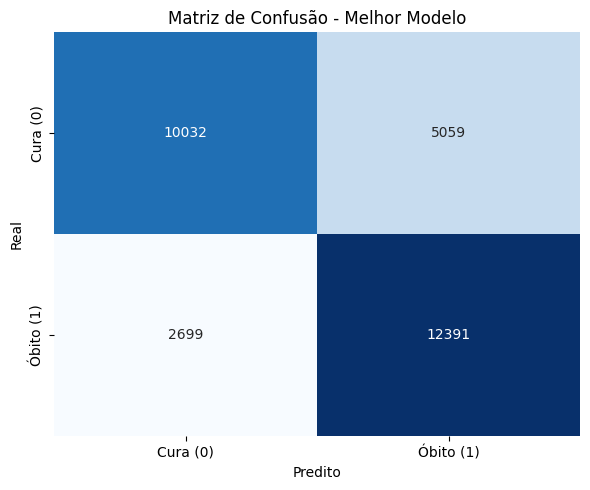

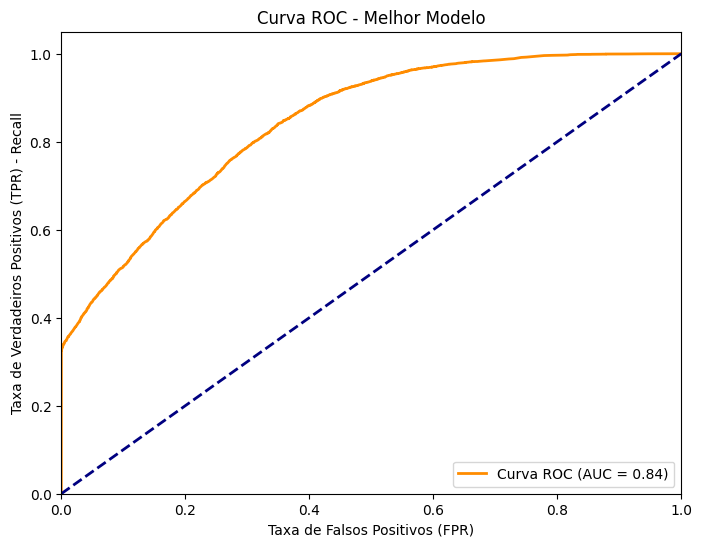


AUC do Modelo: 0.84


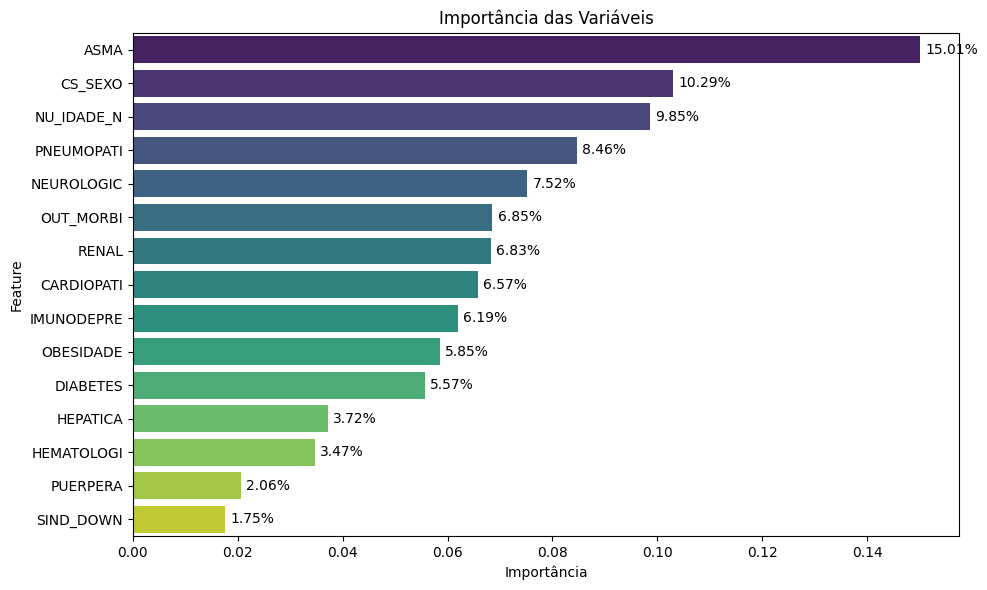

In [23]:
# 📌 3. Pré-processamento
df_filtered = df[df['EVOLUCAO'].isin([1, 2])].copy()
df_filtered.loc[:, 'EVOLUCAO'] = df_filtered['EVOLUCAO'].map({1: 0, 2: 1})

fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

# Garantir que fatores de risco são numéricos
df_filtered.loc[:, fatores_risco] = df_filtered[fatores_risco].apply(pd.to_numeric, errors='coerce')
df_filtered.loc[:, 'NU_IDADE_N'] = pd.to_numeric(df_filtered['NU_IDADE_N'], errors='coerce')
df_filtered.loc[:, 'CS_SEXO'] = df_filtered['CS_SEXO'].map({'M': 0, 'F': 1})

colunas_essenciais = fatores_risco + ['EVOLUCAO', 'NU_IDADE_N', 'CS_SEXO']
df_filtered.dropna(subset=colunas_essenciais, inplace=True)

X = df_filtered[fatores_risco + ['NU_IDADE_N', 'CS_SEXO']].astype(float)  # Garantia de float
y = df_filtered['EVOLUCAO']

print("Primeiras linhas de X após pré-processamento:")
print(X.head())
print("\nDistribuição de y após pré-processamento:")
print(y.value_counts())

# 📌 4. Balanceamento
print(f"\nBalanceamento antes: \n{y.value_counts()}")
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print(f"Balanceamento depois: \n{y_res.value_counts()}")

# 📌 5. Treinamento e Otimização com Gradient Boosting ou XGBoost

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

# Escolha o modelo:
# modelo = GradientBoostingClassifier(random_state=42)
modelo = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Definir os parâmetros para GridSearch
if isinstance(modelo, GradientBoostingClassifier):
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    }
else:  # XGBClassifier
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0]
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-Score (macro) na validação cruzada: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# 📌 6. Avaliação Abrangente
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\n--- Avaliação do Melhor Modelo ---")
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

precision_óbitos = precision_score(y_test, y_pred, pos_label=1)
recall_óbitos = recall_score(y_test, y_pred, pos_label=1)
f1_óbitos = f1_score(y_test, y_pred, pos_label=1)

print(f"\nPrecisão para Óbito: {precision_óbitos:.2f}")
print(f"Recall para Óbito: {recall_óbitos:.2f}")
print(f"F1-Score para Óbito: {f1_óbitos:.2f}")

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Melhor Modelo')
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Curva ROC - Melhor Modelo')
plt.legend(loc="lower right")
plt.show()
print(f"\nAUC do Modelo: {roc_auc:.2f}")

# 📌 7. Importância das features
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': best_model.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Variáveis')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()


GradientBoostingClassifier

In [24]:
# 📌 1. Bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score, precision_score, recall_score

from imblearn.over_sampling import SMOTE

# Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier

# XGBoost
from xgboost import XGBClassifier

# 📌 2. Carregar os dados
df = pd.read_csv("/content/drive/MyDrive/TCC I/Analise de Dados/INFLUD24-03-02-2025.csv", sep=";", encoding="latin1", low_memory=False)

Primeiras linhas de X após pré-processamento:
    PUERPERA  CARDIOPATI  HEMATOLOGI  SIND_DOWN  HEPATICA  ASMA  DIABETES  \
3        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
9        2.0         2.0         2.0        2.0       2.0   2.0       1.0   
10       2.0         1.0         2.0        2.0       2.0   2.0       2.0   
12       2.0         2.0         2.0        2.0       2.0   2.0       2.0   
14       2.0         2.0         2.0        2.0       2.0   2.0       2.0   

    NEUROLOGIC  PNEUMOPATI  IMUNODEPRE  RENAL  OBESIDADE  OUT_MORBI  \
3          2.0         2.0         2.0    2.0        2.0        1.0   
9          2.0         2.0         2.0    2.0        2.0        2.0   
10         2.0         2.0         2.0    2.0        2.0        1.0   
12         2.0         2.0         1.0    2.0        2.0        1.0   
14         2.0         1.0         2.0    2.0        2.0        2.0   

    NU_IDADE_N CS_SEXO  
3           72     0.0  
9           63

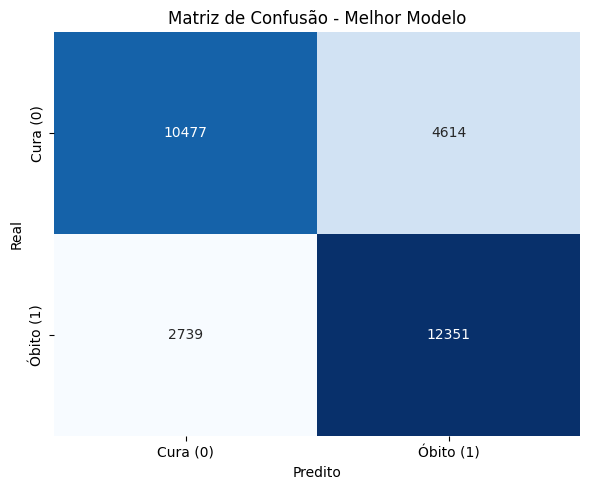

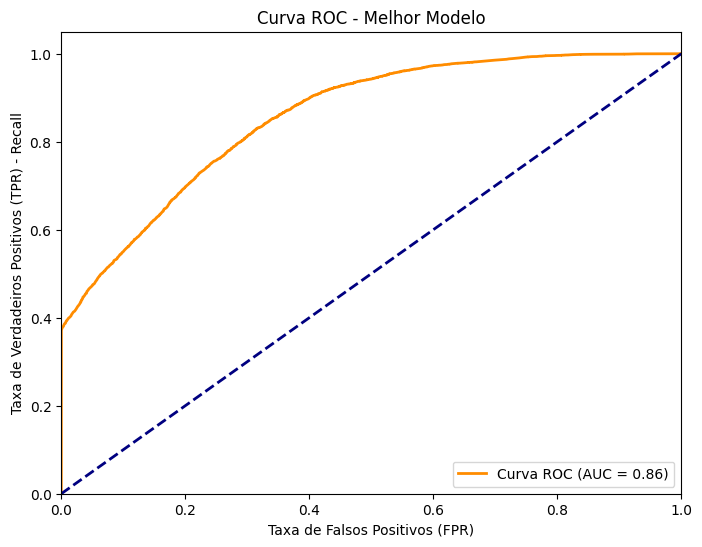


AUC do Modelo: 0.86


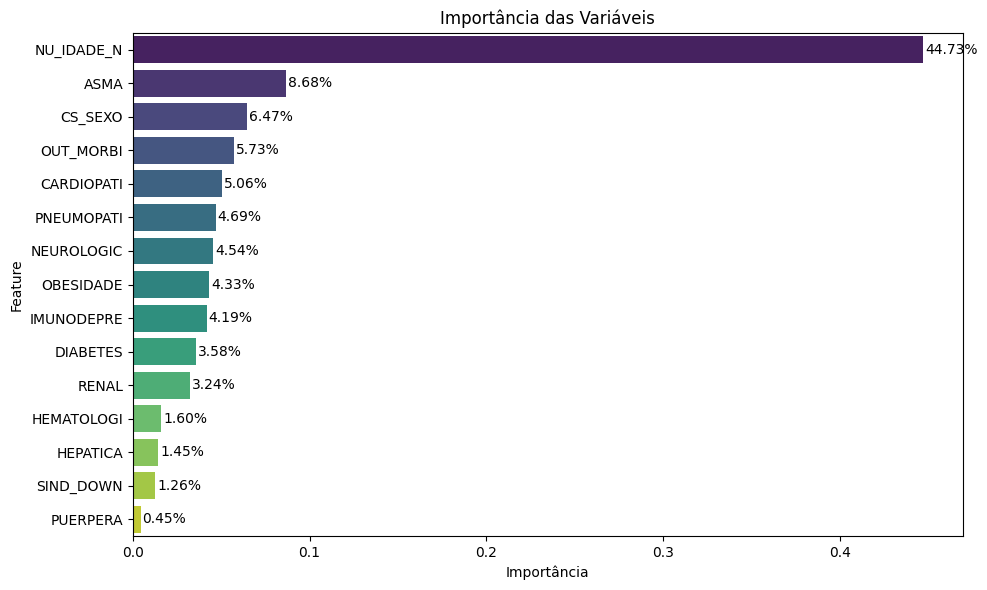

In [25]:
# 📌 3. Pré-processamento
df_filtered = df[df['EVOLUCAO'].isin([1, 2])].copy()
df_filtered.loc[:, 'EVOLUCAO'] = df_filtered['EVOLUCAO'].map({1: 0, 2: 1})

fatores_risco = [
    'PUERPERA', 'CARDIOPATI', 'HEMATOLOGI', 'SIND_DOWN', 'HEPATICA',
    'ASMA', 'DIABETES', 'NEUROLOGIC', 'PNEUMOPATI', 'IMUNODEPRE',
    'RENAL', 'OBESIDADE', 'OUT_MORBI'
]

df_filtered.loc[:, fatores_risco] = df_filtered[fatores_risco].apply(pd.to_numeric, errors='coerce')
df_filtered.loc[:, 'NU_IDADE_N'] = pd.to_numeric(df_filtered['NU_IDADE_N'], errors='coerce')
df_filtered.loc[:, 'CS_SEXO'] = df_filtered['CS_SEXO'].map({'M': 0, 'F': 1})

colunas_essenciais = fatores_risco + ['EVOLUCAO', 'NU_IDADE_N', 'CS_SEXO']
df_filtered.dropna(subset=colunas_essenciais, inplace=True)

X = df_filtered[fatores_risco + ['NU_IDADE_N', 'CS_SEXO']]
y = df_filtered['EVOLUCAO']

print("Primeiras linhas de X após pré-processamento:")
print(X.head())
print("\nDistribuição de y após pré-processamento:")
print(y.value_counts())

# 📌 4. Balanceamento
print(f"Balanceamento antes: \n{y.value_counts()}")
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
print(f"Balanceamento depois: \n{y_res.value_counts()}")

# 📌 5. Treinamento e Otimização com Gradient Boosting ou XGBoost

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.3, random_state=42, stratify=y_res
)

# Escolha o modelo:
modelo = GradientBoostingClassifier(random_state=42)
#modelo = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)

# Definir os parâmetros para GridSearch
if isinstance(modelo, GradientBoostingClassifier):
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'min_samples_split': [2, 5]
    }
else:  # XGBClassifier
    param_grid = {
        'n_estimators': [100, 200],
        'learning_rate': [0.05, 0.1],
        'max_depth': [3, 5],
        'subsample': [0.8, 1.0]
    }

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=modelo,
    param_grid=param_grid,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print(f"\nMelhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-Score (macro) na validação cruzada: {grid_search.best_score_:.4f}")

best_model = grid_search.best_estimator_

# 📌 6. Avaliação Abrangente
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print("\n--- Avaliação do Melhor Modelo ---")
print("📊 Classification Report:\n", classification_report(y_test, y_pred))

precision_óbitos = precision_score(y_test, y_pred, pos_label=1)
recall_óbitos = recall_score(y_test, y_pred, pos_label=1)
f1_óbitos = f1_score(y_test, y_pred, pos_label=1)

print(f"\nPrecisão para Óbito: {precision_óbitos:.2f}")
print(f"Recall para Óbito: {recall_óbitos:.2f}")
print(f"F1-Score para Óbito: {f1_óbitos:.2f}")

print("\nMatriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Cura (0)', 'Óbito (1)'],
            yticklabels=['Cura (0)', 'Óbito (1)'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Melhor Modelo')
plt.tight_layout()
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR) - Recall')
plt.title('Curva ROC - Melhor Modelo')
plt.legend(loc="lower right")
plt.show()
print(f"\nAUC do Modelo: {roc_auc:.2f}")

# 📌 7. Importância das features
importancias = pd.DataFrame({
    'Feature': X.columns,
    'Importância': best_model.feature_importances_
}).sort_values(by='Importância', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importância', y='Feature', data=importancias, palette='viridis', hue='Feature', legend=False)
plt.title('Importância das Variáveis')
for i, v in enumerate(importancias['Importância']):
    plt.text(v + 0.001, i, f"{v:.2%}", va='center')
plt.tight_layout()
plt.show()
